# XGBoost depth policies versus fixed depths

Task 10101, ten SMAC seeds, 200 trials.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

HERE = Path.cwd()
if HERE.name != "03_depth_policies_task_10101" or HERE.parent.name != "xgboost":
    HERE = Path("experiments/HPOBENCH_depths/xgboost/03_depth_policies_task_10101").resolve()
fixed_paths = sorted((HERE.parent / "01_initial" / "smac_output").glob("depth_*/*/trajectory.json"))
policy_paths = sorted((HERE / "smac_output").glob("*/*/trajectory.json"))
if not fixed_paths or not policy_paths:
    raise FileNotFoundError("Run both 01_initial fixed depths and run_depth_policies.py first.")
results = []
for path in fixed_paths:
    result = json.loads(path.read_text()); result["series"] = f"fixed depth {result['max_depth']}"; result["kind"] = "fixed"; results.append(result)
for path in policy_paths:
    result = json.loads(path.read_text()); result["series"] = result["policy"]; result["kind"] = "policy"; results.append(result)
print(f"Loaded {len(fixed_paths)} fixed and {len(policy_paths)} policy trajectories.")
rows = []
for result in results:
    rows.extend({"series": result["series"], "kind": result["kind"], "seed": result["smac_seed"], "iteration": i, "best_so_far": best} for i, best in zip(result["iteration"], result["best_so_far"]))
trajectories = pd.DataFrame(rows)
SERIES = ["fixed depth 2", "fixed depth 4", "fixed depth 8", "fixed depth 12", "fixed depth 20", "rotate_10", "staged_80_50_rest"]
colors = dict(zip(SERIES, plt.cm.tab10(np.arange(len(SERIES)))))

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 668,

Loaded 50 fixed and 20 policy trajectories.


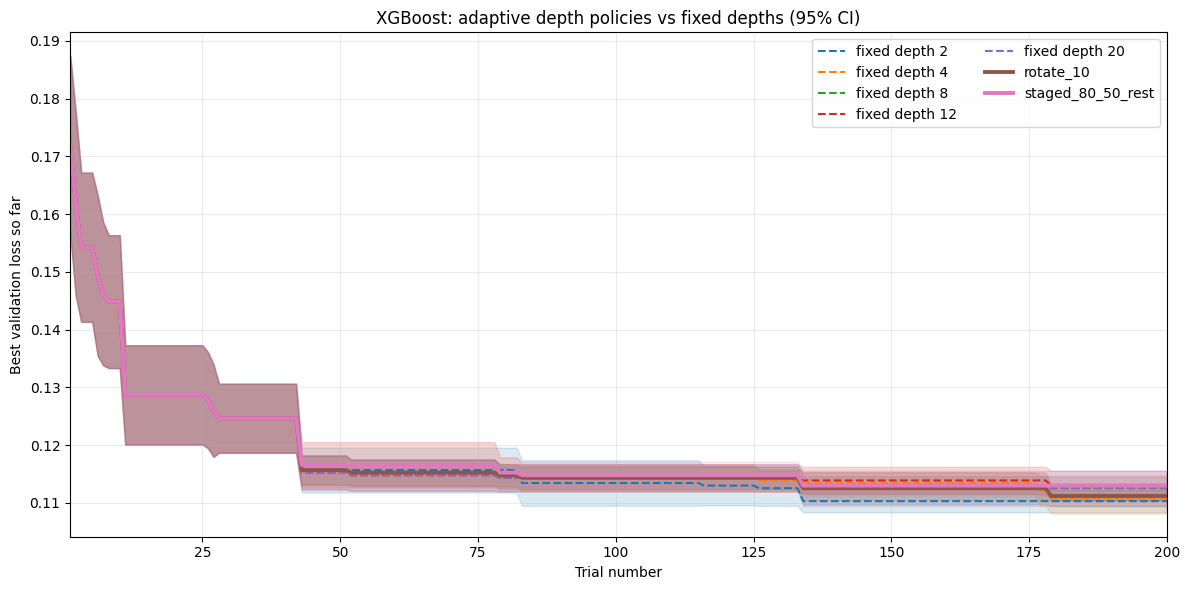

In [2]:
summary = trajectories.groupby(["series", "kind", "iteration"])["best_so_far"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"].fillna(0) / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(12, 6))
for name in SERIES:
    data = summary[summary["series"] == name]
    x, mean, ci = data["iteration"].to_numpy(), data["mean"].to_numpy(), data["ci95"].to_numpy()
    is_policy = name in {"rotate_10", "staged_80_50_rest"}
    ax.plot(x, mean, color=colors[name], linestyle="-" if is_policy else "--", linewidth=2.8 if is_policy else 1.5, label=name)
    ax.fill_between(x, mean-ci, mean+ci, color=colors[name], alpha=0.16)
ax.set(title="XGBoost: adaptive depth policies vs fixed depths (95% CI)", xlabel="Trial number", ylabel="Best validation loss so far", xlim=(1, 200))
ax.grid(alpha=0.25); ax.legend(ncol=2); plt.tight_layout(); plt.show()

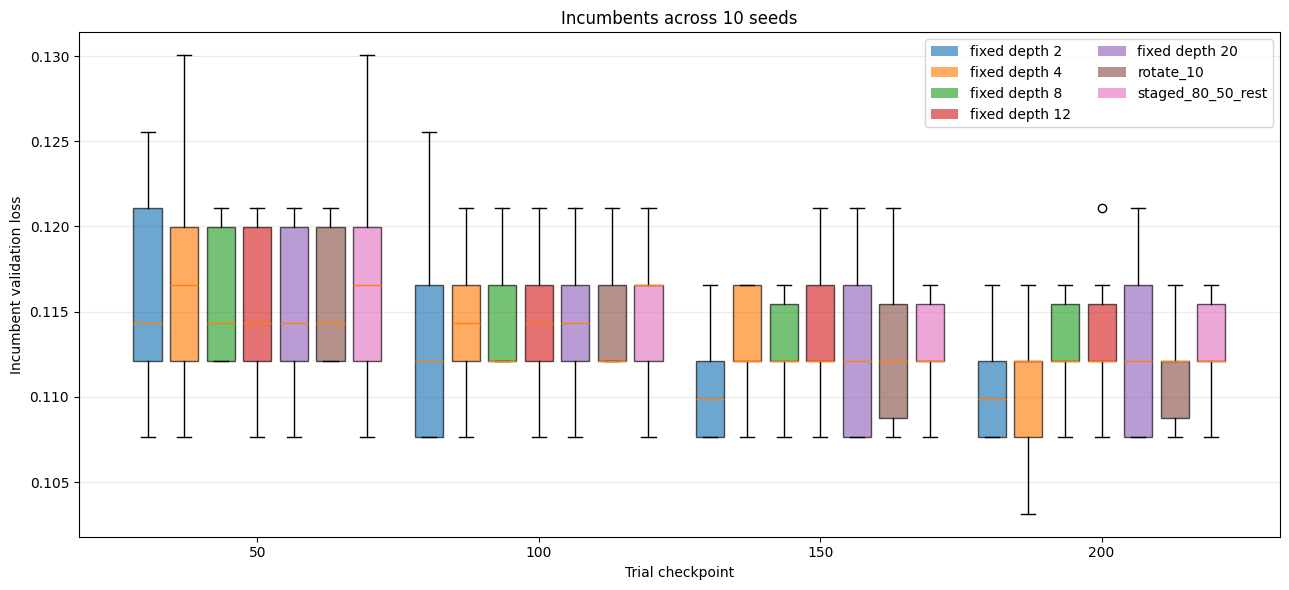

,count,mean,std,min,25%,50%,75%,max
series,,,,,,,,
fixed depth 2,10.0,0.110314,0.003135,0.107623,0.107623,0.109865,0.112108,0.116592
fixed depth 4,10.0,0.110762,0.004254,0.103139,0.107623,0.112108,0.112108,0.116592
fixed depth 8,10.0,0.112556,0.003309,0.107623,0.112108,0.112108,0.115471,0.116592
fixed depth 12,10.0,0.113004,0.004121,0.107623,0.112108,0.112108,0.115471,0.121076
fixed depth 20,10.0,0.112556,0.004935,0.107623,0.107623,0.112108,0.116592,0.121076
rotate_10,10.0,0.111211,0.002836,0.107623,0.108744,0.112108,0.112108,0.116592
staged_80_50_rest,10.0,0.113004,0.002836,0.107623,0.112108,0.112108,0.115471,0.116592


In [3]:
checkpoints = (50, 100, 150, 200)
base = np.arange(len(checkpoints)); offsets = dict(zip(SERIES, np.linspace(-0.39, 0.39, len(SERIES))))
fig, ax = plt.subplots(figsize=(13, 6))
for name in SERIES:
    values = [trajectories.loc[(trajectories["series"] == name) & (trajectories["iteration"] == cp), "best_so_far"].to_numpy() for cp in checkpoints]
    boxes = ax.boxplot(values, positions=base+offsets[name], widths=0.1, patch_artist=True, manage_ticks=False)
    for box in boxes["boxes"]: box.set(facecolor=colors[name], alpha=0.65)
ax.set(title="Incumbents across 10 seeds", xlabel="Trial checkpoint", ylabel="Incumbent validation loss", xticks=base, xticklabels=checkpoints)
ax.legend(handles=[Patch(facecolor=colors[n], alpha=0.65, label=n) for n in SERIES], ncol=2); ax.grid(axis="y", alpha=0.25); plt.tight_layout(); plt.show()
trajectories[trajectories["iteration"] == 200].groupby("series")["best_so_far"].describe().loc[SERIES]